# Загрузка библиотек

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import warnings

from grokking_model import GrokkingTransformer
from grokking_utils import get_modular_addition_data, get_weight_norm

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
torch.set_default_dtype(torch.float64)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cpu


# МАТЕМАТИКА: MLE РАЗМЕРНОСТЬ БАТЧА В ПРОСТРАНСТВЕ

In [2]:
def compute_batch_mle_dim(H, k=5):
    """
    Вычисляет эффективную размерность облака активаций (H) для батча.
    H имеет размер [batch_size, hidden_dim].
    """
    if H.size(0) < k + 2:
        return np.nan
        
    # Добавляем нано-шум, чтобы точки не слипались при идеальной меморизации
    H = H + torch.randn_like(H) * 1e-9
    
    # Считаем попарные расстояния между всеми примерами в батче
    dist_matrix = torch.cdist(H, H, p=2)
    
    # Ищем k+1 ближайших соседей (0-й сосед - сама точка, его отбросим)
    distances, _ = torch.topk(dist_matrix, k=k+1, dim=1, largest=False)
    distances = distances[:, 1:] # [batch_size, k]
    distances = torch.clamp(distances, min=1e-8) # Защита от деления на 0
    
    r_k = distances[:, -1:] # Радиус до k-го соседа
    log_ratios = torch.log(r_k / distances[:, :-1])
    sum_log_ratios = torch.sum(log_ratios, dim=1)
    sum_log_ratios = torch.clamp(sum_log_ratios, min=1e-5)
    
    # Локальная размерность каждого примера
    local_id = (k - 1) / sum_log_ratios
    
    # Фильтруем мусор и усредняем по всему батчу
    valid_mask = torch.isfinite(local_id)
    if not valid_mask.any():
        return np.nan
        
    global_dim = local_id[valid_mask].mean().item()
    return min(max(global_dim, 1.0), 50.0) # Обрезаем выбросы сверху до 50

# Генерация и предобработка данных

In [3]:
P = 113
FRACTION = 0.3

X_train, Y_train, X_test, Y_test, num_total = get_modular_addition_data(
    p=P, fraction=FRACTION, seed=42, device=device
)

BATCH_SIZE = 256
VAL_BATCH_SIZE = 512

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

fixed_val_x = X_test[:VAL_BATCH_SIZE]
fixed_val_y = Y_test[:VAL_BATCH_SIZE]

print(f"Train size: {len(X_train)} | Fixed Val size: {len(fixed_val_x)}")

Train size: 3830 | Fixed Val size: 512


# Архитектура модели

In [6]:
model = GrokkingTransformer(d_vocab=P + 1).to(device)

# --- МАГИЯ ХУКОВ ---
# Мы будем перехватывать тензор прямо перед последним слоем
activation_cache = {}
def get_activation(name):
    def hook(model, input):
        # input[0] - это тензор, входящий в unembed layer
        activation_cache[name] = input[0].detach() 
    return hook

# Вешаем "прослушку" на линейный слой unembed
model.unembed.register_forward_pre_hook(get_activation('unembed'))

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
criterion = nn.CrossEntropyLoss()

MAX_STEPS = 20000
LOG_FREQ = 10

logs = {
    'step': [], 'train_loss': [], 'val_loss':[], 
    'train_acc':[], 'val_acc': [], 'weight_norm':[], 'batch_dim': []
}

# Обучение

In [8]:
print("\nStarting Mini-Batch Grokking Training with Spatial Dimension Tracking...")
global_step = 0
loop = tqdm(total=MAX_STEPS)

while global_step < MAX_STEPS:
    for batch_x, batch_y in train_loader:
        if global_step >= MAX_STEPS:
            break

        model.train()
        optimizer.zero_grad()

        logits_train = model(batch_x)
        train_loss = criterion(logits_train, batch_y)
        train_loss.backward()
        optimizer.step()

        if global_step % LOG_FREQ == 0:
            with torch.no_grad():
                model.eval()
                acc_train = (logits_train.argmax(dim=1) == batch_y).float().mean().item()

                # Прогоняем валидацию. Хук автоматически сохранит эмбеддинги в activation_cache!
                logits_val = model(fixed_val_x)
                val_loss = criterion(logits_val, fixed_val_y)
                acc_val = (logits_val.argmax(dim=1) == fixed_val_y).float().mean().item()

                # ДОСТАЕМ СОХРАНЕННЫЕ ЭМБЕДДИНГИ ВАЛИДАЦИОННОГО БАТЧА
                H_val = activation_cache['unembed']
                # Считаем их пространственную размерность
                if H_val.dim() == 3:
                    H_val = H_val[:, -1, :] 
                
                # Теперь H_val имеет размер [512, 128], и соседей среди 512 примеров найти легко
                current_batch_dim = compute_batch_mle_dim(H_val, k=5)

                w_norm = get_weight_norm(model)

                logs['step'].append(global_step)
                logs['train_loss'].append(train_loss.item())
                logs['val_loss'].append(val_loss.item())
                logs['train_acc'].append(acc_train)
                logs['val_acc'].append(acc_val)
                logs['weight_norm'].append(w_norm)
                logs['batch_dim'].append(current_batch_dim)

                if global_step % 500 == 0:
                    loop.set_postfix(v_acc=f"{acc_val:.2f}", norm=f"{w_norm:.1f}", dim=f"{current_batch_dim:.1f}")

        global_step += 1
        loop.update(1)

loop.close()

# Сохранение
df_logs = pd.DataFrame(logs)
csv_name = 'experiments_with_batch_dimensionality.csv'
df_logs.to_csv(csv_name, index=False)
print(f"Logs saved to '{csv_name}'")


Starting Mini-Batch Grokking Training with Spatial Dimension Tracking...


  0%|          | 0/20000 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Итоговые графики


Generating Spatial Dimensionality Plot...


NameError: name 'df_logs' is not defined

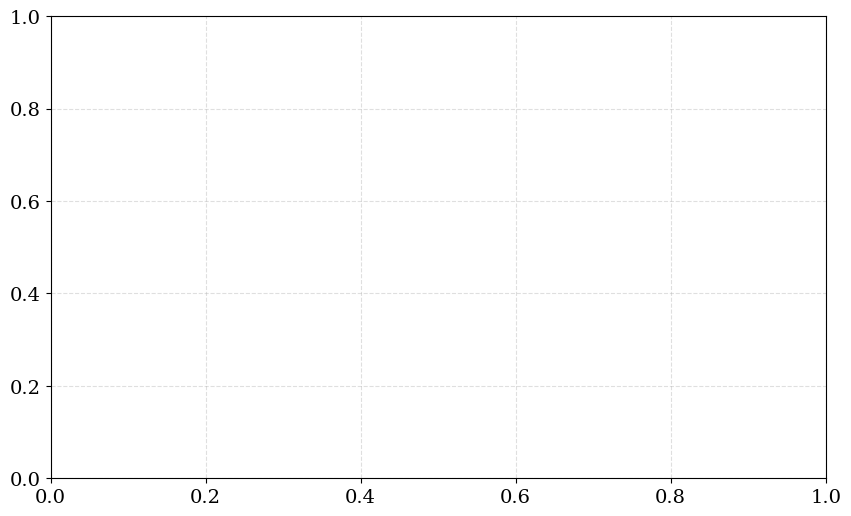

In [9]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--'
})

print("\nGenerating Spatial Dimensionality Plot...")

fig, ax1 = plt.subplots(figsize=(10, 6))

steps = df_logs['step'].values
batch_dim = df_logs['batch_dim'].values
train_acc = df_logs['train_acc'].values
val_acc = df_logs['val_acc'].values

# --- ЛЕВАЯ ОСЬ (Размерность Активаций) ---
color_E = 'tab:purple'
ax1.set_xlabel('Optimization Steps', fontsize=14, fontweight='bold')
ax1.set_ylabel('Spatial Dimensionality of Embeddings', color=color_E, fontsize=14, fontweight='bold')

# Сгладим размерность для красоты графика (скользящее среднее 5 точек)
batch_dim_smooth = pd.Series(batch_dim).rolling(window=5, min_periods=1).mean().values

line_E, = ax1.plot(steps, batch_dim_smooth, color=color_E, linewidth=2.5, label='Activation Dim (MLE)')
ax1.tick_params(axis='y', labelcolor=color_E)

# Задаем масштаб Y для размерности
valid_dim = batch_dim[~np.isnan(batch_dim)]
ax1.set_ylim(0, max(valid_dim) + 2)

# --- ПРАВАЯ ОСЬ (Accuracy) ---
ax2 = ax1.twinx()
color_tr = 'tab:blue'
color_val = 'tab:red'
ax2.set_ylabel('Accuracy', color='black', fontsize=14, fontweight='bold')

line_tr, = ax2.plot(steps, train_acc, color=color_tr, alpha=0.3, label='Train Acc')
line_val, = ax2.plot(steps, val_acc, color=color_val, linewidth=2.5, label='Val Acc')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(-0.05, 1.05)

# Ищем точку гроккинга
grok_df = df_logs[df_logs['val_acc'] >= 0.95]
if not grok_df.empty:
    grok_step = grok_df['step'].iloc[0]
    ax2.axvline(x=grok_step, color='black', linestyle=':', linewidth=2)
    ax2.annotate('Grokking Point', xy=(grok_step, 0.2), xytext=(grok_step + 1000, 0.2),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                 fontsize=12, fontweight='bold')

lines = [line_E, line_tr, line_val]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', framealpha=0.9, fontsize=11)

plt.title('Collapse of Spatial Dimensionality during Grokking\n(MLE measured directly on batch hidden states)', fontsize=15)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('spatial_dim_grokking.png', format='png', dpi=300)
plt.show()

print("Plot saved to 'experiments_with_batch_dimensionality.png'")